<a href="https://colab.research.google.com/github/biplabp455/Skill-Morph-ML-Training/blob/main/Phishing_site_detection_with_Machine_learning_algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
X(important_features): (10000, 50)
y(CLASS_LABEL): (10000,)
Teaching phishing analyser with training data...
Phishing analysers training has completed!
Now let's see how good our analyser is...
Phishing analyser made prediction for all test features
\Phishing Analyser Accuracy: 0.961 (96.1%)
Excellent! Our Phishing Analyser is very accurate

Confusion Matrix:
[[2391  102]
 [  95 2412]]

Correct: 4803

Incorrect: 197


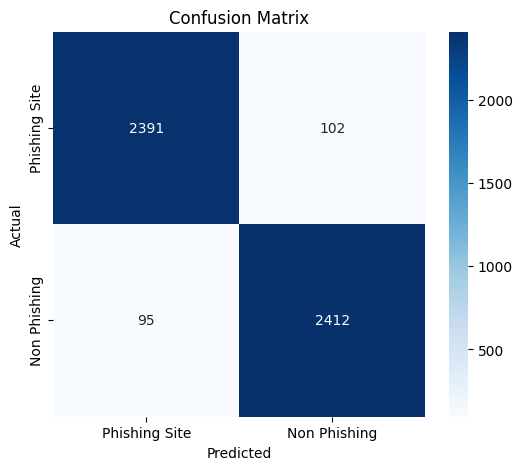


Accuracy : 0.96
precision: 0.96
recall: 0.96
f1: 0.96


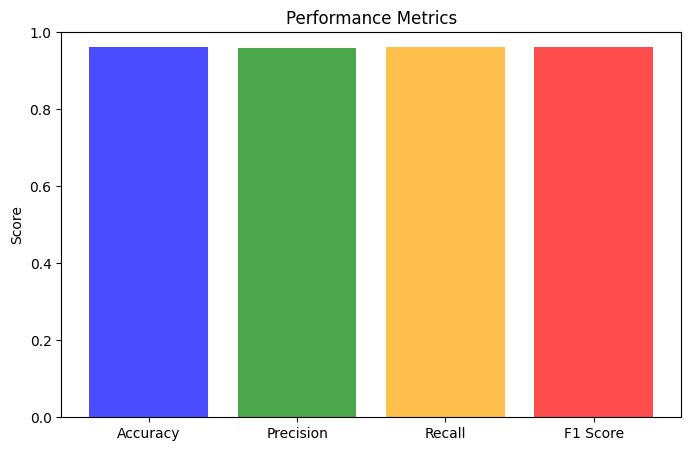

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import(accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score)
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')
dataset = pd.read_csv('/content/drive/MyDrive/Dataset/Phishing_Legitimate_full.csv')
#dataset.head()
important_features = ['NumDots','SubdomainLevel', 'PathLevel', 'UrlLength', 'NumDash', 'AtSymbol', 'NumPercent', 'NumQueryComponents', 'NoHttps', 'RandomString', 'IpAddress',
                      'DomainInSubdomains',
                      'DomainInPaths',
                      'HttpsInHostname',
                      'HttpsInHostname',
                      'PathLength',
                      'QueryLength',
                      'InsecureForms',
                      'RelativeFormAction',
                      'AbnormalFormAction',
                      'FakeLinkInStatusBar',
                      'RightClickDisabled',
                      'MissingTitle',
                      'ImagesOnlyInForm',
                      'SubdomainLevelRT',
                      'UrlLengthRT',
                      'PctExtResourceUrlsRT',
                      'AbnormalExtFormActionR',
                      'ExtMetaScriptLinkRT',
                      'PctExtNullSelfRedirectHyperlinksRT','NumDashInHostname', 'TildeSymbol', 'NumUnderscore', 'NumAmpersand','NumHash',
                      'NumNumericChars', 'HostnameLength', 'DoubleSlashInPath', 'NumSensitiveWords', 'EmbeddedBrandName', 'PctExtHyperlinks',
                      'PctExtResourceUrls', 'ExtFavicon', 'InsecureForms', 'ExtFormAction', 'FrequentDomainNameMismatch', 'FakeLinkInStatusBar',
                      'PopUpWindow', 'SubmitInfoToEmail', 'IframeOrFrame']
#Creating a simple dataset
X = dataset[important_features]
y = dataset['CLASS_LABEL']

print(f"X(important_features): {X.shape}")
print(f"y(CLASS_LABEL): {y.shape}")

# Train and Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=20)
#print(f"Training: {len(X_train)} possibility (computer will learn from these)")
#print(f"Testing: {len(X_test)} possibility (computer will be tested on these)")
#print(f"\training examples (computer learns from these):" )
#print(X_train.head())
#print(X_test.head())

# Now we will train the model with decision tree
#Creating model
phishing_analyser = DecisionTreeClassifier(
    max_depth = 15, #keep it simple
    random_state = 20
)
print("Teaching phishing analyser with training data...")
#train the model
phishing_analyser.fit(X_train, y_train)
print("Phishing analysers training has completed!")
print("Now let's see how good our analyser is...")
#make prediction
predictions = phishing_analyser.predict(X_test)
print("Phishing analyser made prediction for all test features")
#Calculate accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"\Phishing Analyser Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")
if accuracy>0.95:
  print("Excellent! Our Phishing Analyser is very accurate")
elif accuracy>0.90:
  print("Good job! Our Phishing Analyser performs well")
elif accuracy>0.80:
  print("Ok! Our Phishing Analyser is decent")
else:
  print("Need to improve Phishing Analyser")
# Now calculate the Confusion Matrix
cm = confusion_matrix(y_test, predictions)
print("\nConfusion Matrix:")
print(cm)
print(f"\nCorrect: {cm[0,0] + cm[1,1]}")
print(f"\nIncorrect: {cm[0,1] + cm[1,0]}")
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels= ['Phishing Site', 'Non Phishing'],
            yticklabels= ['Phishing Site', 'Non Phishing'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Matrix Calculation
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)

# Now we will print them

print(f"\nAccuracy : {accuracy:.2f}")
print(f"precision: {precision:.2f}")
print(f"recall: {recall:.2f}")
print(f"f1: {f1:.2f}")

#Display it in simple bar chart

plt.figure(figsize=(8, 5))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]
plt.bar(metrics, values, color=['Blue', 'Green', 'Orange', 'Red'], alpha = 0.7)
plt.ylim(0, 1)
plt.title('Performance Metrics')
plt.ylabel('Score')
plt.show()
